## Olympics Analysis

### 1. Database connection and SQL query

In [1]:
# Import modules

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

In [2]:
# Establish connection

load_dotenv("../.env")
db_url = os.getenv("DATABASE_URL", default=None)
assert db_url is not None, "DATABASE_URL not found in .env"
engine = create_engine(db_url)

In [3]:
df = pd.read_sql("""
    SELECT 
        a.name,
        a.sex,
        s.sport,
        d.year,
        m.medal_name,
        e.name AS event_name,
        f.age_at_event,
        f.body_size_at_event,
        f.body_weight_at_event,
        c.country_name
    FROM fact_medals f
        JOIN dim_athletes a     ON f.athlete            = a.athleteid
        JOIN dim_event e        ON f.event              = e.eventid
        JOIN dim_sport s        ON e.sportid            = s.sportid
        JOIN dim_date d         ON f.dateid             = d.dateid
        JOIN dim_countries c    ON f.country_at_event   = c.countryid
        LEFT JOIN dim_medal m   ON f.medal              = m.medalid
""", engine)

### 2. Exploratory Data Analysis

In [4]:
# General Overview

print(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165978 entries, 0 to 165977
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   name                  165978 non-null  object 
 1   sex                   165978 non-null  object 
 2   sport                 165978 non-null  object 
 3   year                  165978 non-null  int64  
 4   medal_name            23536 non-null   object 
 5   event_name            165978 non-null  object 
 6   age_at_event          165978 non-null  int64  
 7   body_size_at_event    158604 non-null  float64
 8   body_weight_at_event  158277 non-null  float64
 9   country_name          165959 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 12.7+ MB
None


,year,age_at_event,body_size_at_event,body_weight_at_event
count,165978.000000,165978.000000,158604.000000,158277.000000
mean,1991.359795,24.821862,1755.384858,706.471073
std,16.811584,5.992564,110.561177,149.443828
min,1960.000000,0.000000,1270.000000,77.000000
25%,1976.000000,21.000000,1680.000000,600.000000
50%,1992.000000,24.000000,1750.000000,700.000000
75%,2004.000000,28.000000,1830.000000,790.000000
max,2016.000000,71.000000,2260.000000,2140.000000


In [5]:
# Data quality - missing values

# Percentage distribution of missing values
print(df.isna().sum().sort_values(ascending=False))
print(df.isna().mean().sort_values(ascending=False) * 100)
print(df.shape)

medal_name              142442
body_weight_at_event      7701
body_size_at_event        7374
country_name                19
sex                          0
name                         0
event_name                   0
year                         0
sport                        0
age_at_event                 0
dtype: int64
medal_name              85.819807
body_weight_at_event     4.639772
body_size_at_event       4.442757
country_name             0.011447
sex                      0.000000
name                     0.000000
event_name               0.000000
year                     0.000000
sport                    0.000000
age_at_event             0.000000
dtype: float64
(165978, 10)


**Result:**
- Missing values are present in country_name, body_weight and body_size.
- Strategy for country_name: Delete, as there is very little data and it is categorical
- Strategy for body_*: Further investigation (see below)

In [6]:
print(df["body_weight_at_event"].isnull().groupby([df["year"], df["sport"]]).sum().sort_values(ascending=False))
print(f"\n{"-"*90}\n")
print(df[df["sport"] == "Swimming"].info())

year  sport        
1992  Swimming         483
1996  Swimming         364
1992  Gymnastics       262
1976  Swimming         257
1996  Gymnastics       215
                      ... 
2016  Trampolining       0
      Volleyball         0
      Water Polo         0
      Weightlifting      0
      Wrestling          0
Name: body_weight_at_event, Length: 409, dtype: int64

------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 19866 entries, 19 to 165964
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  19866 non-null  object 
 1   sex                   19866 non-null  object 
 2   sport                 19866 non-null  object 
 3   year                  19866 non-null  int64  
 4   medal_name            2429 non-null   object 
 5   event_name            19866 non-null  object 
 6   age_at_event     

**Result:**
- Certain sports are more affected by missing data (swimming, gymnastics) -> Missing not at random (MNAR)
- For the sport of swimming and gymnastics, approximately 7% of the data for weight and height is missing. It seems sensible to impute these values using the median for each sport and gender

In [7]:
# Perform data cleansing

print(f"Rows before dropna: {len(df)}")
df = df.dropna(subset=['country_name']) # Remove rows without 'country_name'
print(f"Rows after dropna: {len(df)}")

Rows before dropna: 165978
Rows after dropna: 165959


In [8]:
# Perform imputation

df['body_size_at_event'] = df.groupby(['sport', 'sex'])['body_size_at_event'].transform(lambda x: x.fillna(x.median()))

df['body_weight_at_event'] = df.groupby(['sport', 'sex'])['body_weight_at_event'].transform(lambda x: x.fillna(x.median()))

In [9]:
print(df[['body_size_at_event', 'body_weight_at_event']].isna().sum())

body_size_at_event      0
body_weight_at_event    0
dtype: int64


### 3. Peak age analysis — when do athletes in each sport reach their performance peak?

In [10]:
# Filter by medal winners
mask_medals = df['medal_name'].notnull()
df_peak_age = df[mask_medals]

In [11]:
# Calculate the median age of medallists

df_peak_age.groupby(['sport', 'sex'])['age_at_event'].median().rename("Medianes Medaillenalter")

sport          sex
Archery        F      23.0
               M      24.0
Athletics      F      25.0
               M      25.0
Badminton      F      25.0
                      ... 
Water Polo     M      26.0
Weightlifting  F      23.0
               M      25.0
Wrestling      F      26.0
               M      26.0
Name: Medianes Medaillenalter, Length: 68, dtype: float64

In [12]:
# The age range in which 75% of the medals are awarded

df_peak_age.groupby(['sport', 'sex'])['age_at_event'].quantile([0.125, 0.875]).unstack(level=-1).rename(columns={0.125 : "12.5%-Quartil", 0.875 : "87.5%-Quartil"})

12.5%-Quartil  87.5%-Quartil
sport         sex                              
Archery       F           18.375         29.000
              M           19.000         31.625
Athletics     F           21.000         30.000
              M           21.000         30.000
Badminton     F           21.000         27.000
...                          ...            ...
Water Polo    M           22.000         31.000
Weightlifting F           20.000         27.000
              M           21.000         30.000
Wrestling     F           21.000         31.000
              M           22.000         30.000

[68 rows x 2 columns]

In [13]:
df_peak_summary = pd.concat([df_peak_age.groupby(['sport', 'sex'])['age_at_event'].median().rename("Medianes Medaillenalter"),df_peak_age.groupby(['sport', 'sex'])['age_at_event'].quantile([0.125, 0.875]).unstack(level=-1).rename(columns={0.125 : "12.5%-Quartil", 0.875 : "87.5%-Quartil"})], axis=1)

display(df_peak_summary)

Medianes Medaillenalter  12.5%-Quartil  87.5%-Quartil
sport         sex                                                       
Archery       F                       23.0         18.375         29.000
              M                       24.0         19.000         31.625
Athletics     F                       25.0         21.000         30.000
              M                       25.0         21.000         30.000
Badminton     F                       25.0         21.000         27.000
...                                    ...            ...            ...
Water Polo    M                       26.0         22.000         31.000
Weightlifting F                       23.0         20.000         27.000
              M                       25.0         21.000         30.000
Wrestling     F                       26.0         21.000         31.000
              M                       26.0         22.000         30.000

[68 rows x 3 columns]

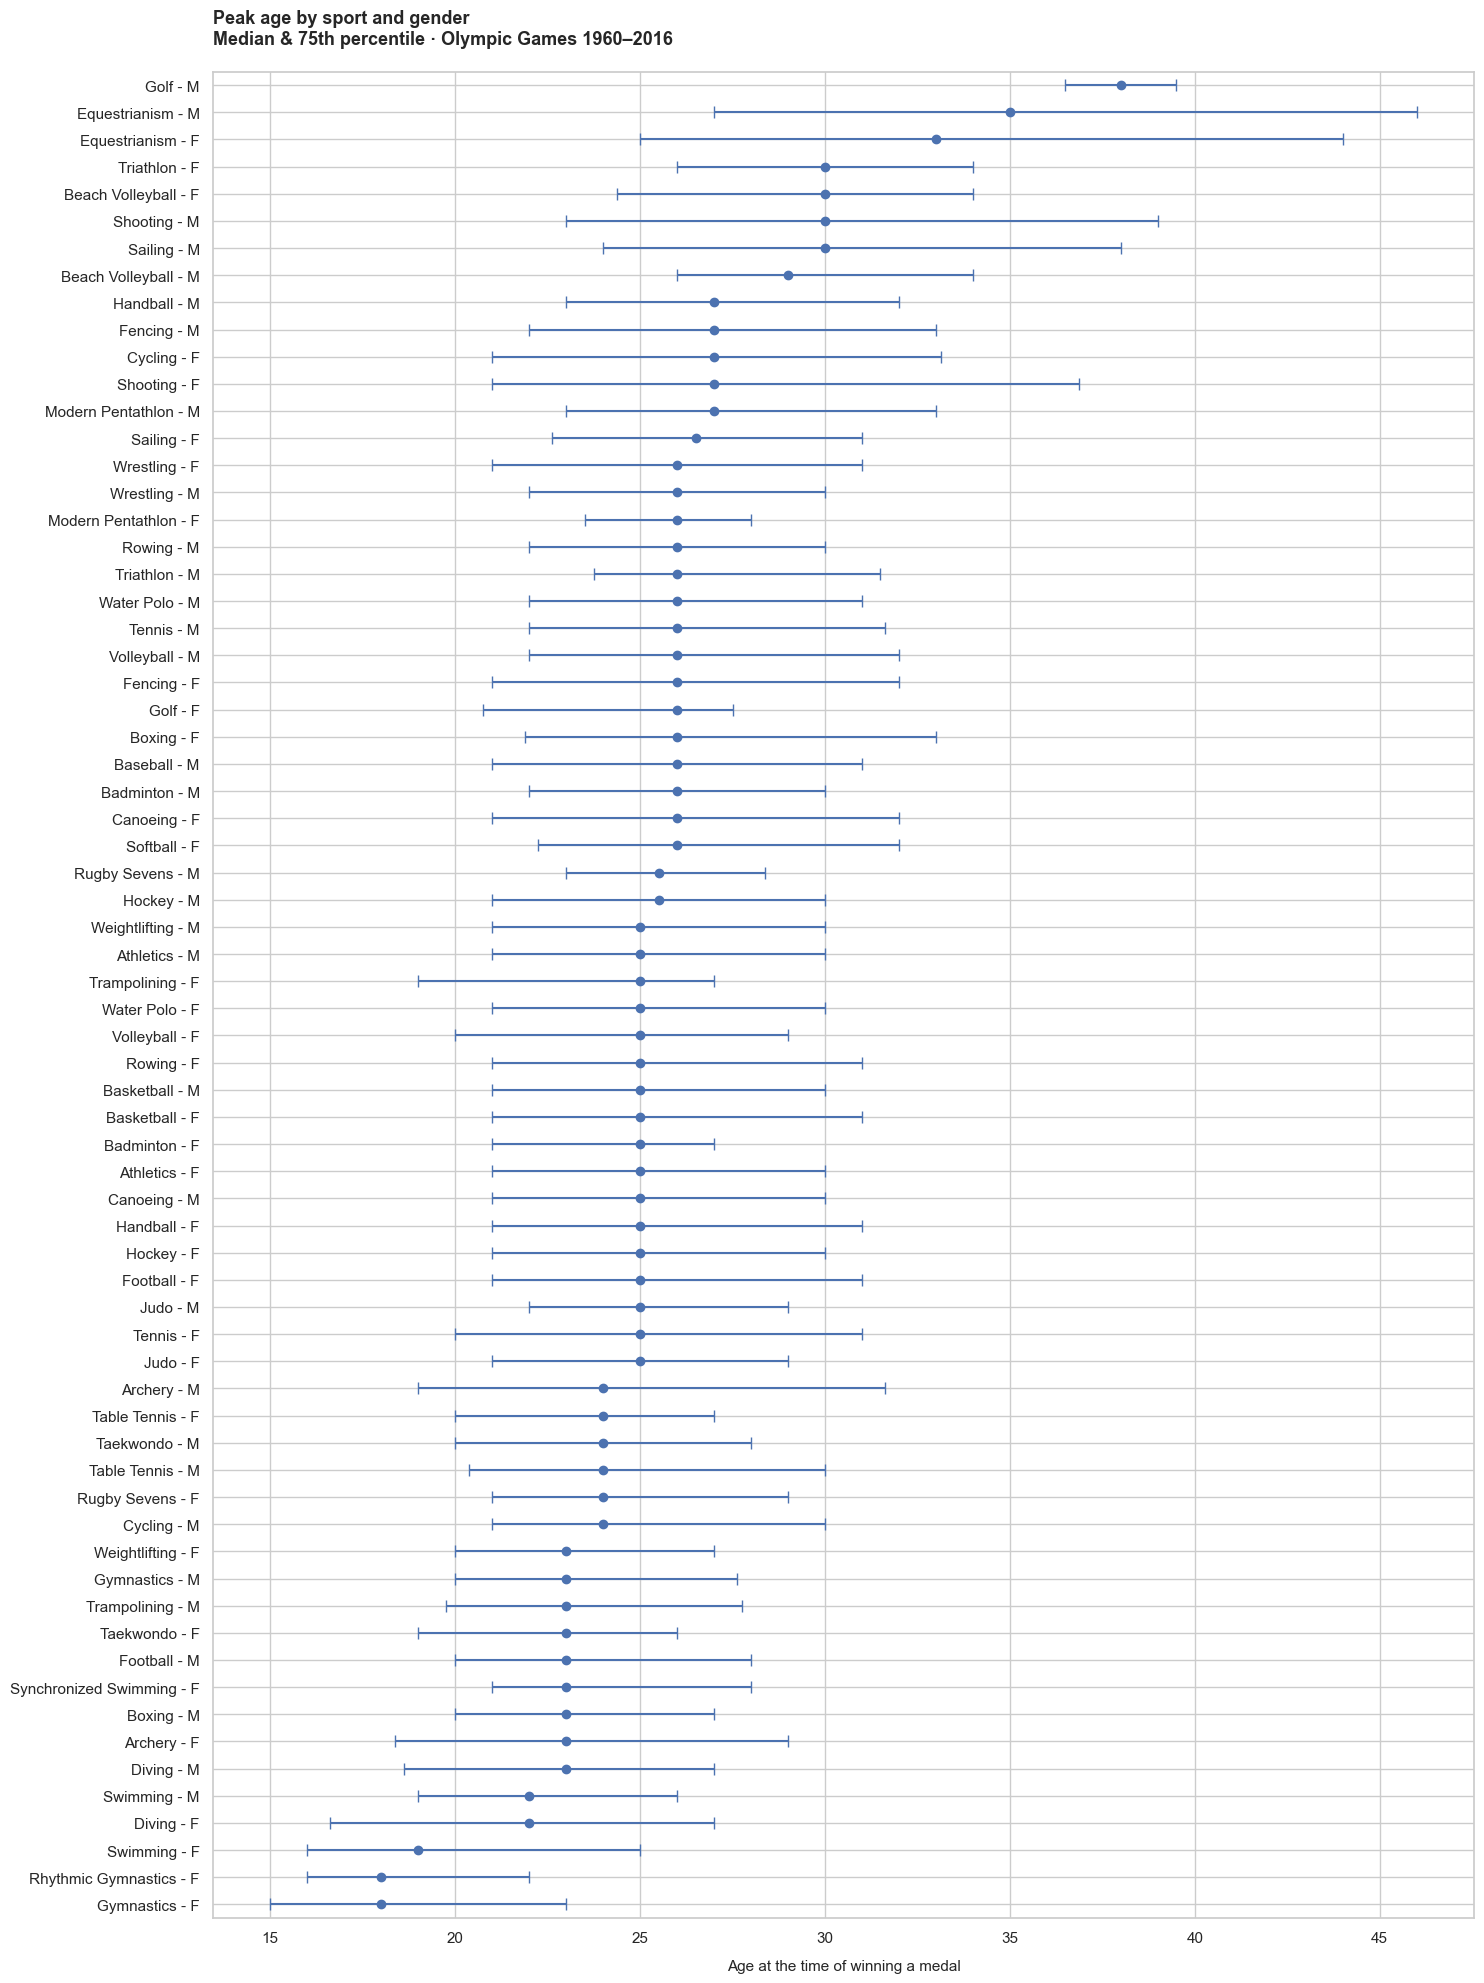

In [14]:
# Vizualize results

df_peak_summary["Lower Border"] = df_peak_summary["Medianes Medaillenalter"] - df_peak_summary["12.5%-Quartil"]
df_peak_summary["Upper Border"] = df_peak_summary["87.5%-Quartil"] - df_peak_summary["Medianes Medaillenalter"]

df_peak_summary = df_peak_summary.sort_values("Medianes Medaillenalter")

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(15, 20))

ax.errorbar(
    x=df_peak_summary["Medianes Medaillenalter"],
    y=[" - ".join([i[0], i[1]]) for i in df_peak_summary.index],
    xerr=[df_peak_summary["Lower Border"], df_peak_summary["Upper Border"]],
    fmt="o",
    capsize=4,
)

ax.set_title("Peak age by sport and gender\nMedian & 75th percentile · Olympic Games 1960–2016",
             fontsize=13, fontweight="bold", loc="left", pad=20)

ax.set_xlabel("Age at the time of winning a medal", fontsize=11, labelpad=10)
ax.set_ylim(-0.5, len(df_peak_summary) - 0.5)

plt.tight_layout()
plt.show()

**Result Peak age analysis**
- Rhythmic Gymnastics (Women): Median age 18  — narrowest performance window
- Equestrianism (Men): Median age 35  — longest performance window
- Most sports: 23–27 years
- Gender difference: greater in physical sports, smaller in technical sports

### 4. Career transition paths — which sports share compatible athlete profiles for post-peak transitions?

In [15]:
# Only medal winners with complete physical measurements

df_career = df[df['medal_name'].notna()].dropna(subset=['body_size_at_event', 'body_weight_at_event', 'age_at_event'])

In [16]:
# Sport profiles (median body size, body weight and age) with named aggregation

sport_profiles = (
    df_career.groupby('sport').agg(
            median_height=('body_size_at_event', 'median'),
            median_weight=('body_weight_at_event', 'median'),
            median_age=('age_at_event', 'median'),
            n=('name', 'nunique')
    ).reset_index()
)

# Filter sports with more than 50 unique medailists
sport_profiles = sport_profiles[sport_profiles["n"] > 50]

In [17]:
# Scale normalisation is required

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_scaled = scaler.fit_transform(sport_profiles[['median_height', 'median_weight', 'median_age']])

In [18]:
# Calculate distance between sports

from scipy.spatial.distance import cdist

dist_matrix = cdist(features_scaled, features_scaled, metric='euclidean')

dist_df = pd.DataFrame(
    dist_matrix,
    index=sport_profiles['sport'].values,
    columns=sport_profiles['sport'].values
)

print(dist_df)

                        Archery  Athletics  Badminton  Baseball  Basketball  \
Archery                0.000000   1.074839   0.462871  2.549005    3.760038   
Athletics              1.074839   0.000000   0.723045  2.032763    2.969803   
Badminton              0.462871   0.723045   0.000000  2.343371    3.532603   
Baseball               2.549005   2.032763   2.343371  0.000000    1.634151   
Basketball             3.760038   2.969803   3.532603  1.634151    0.000000   
Beach Volleyball       3.483927   2.600222   3.078909  1.882721    2.102837   
Boxing                 0.756832   1.023469   0.856629  2.843521    3.768996   
Canoeing               1.794821   1.272897   1.600405  0.817466    2.038713   
Cycling                1.132182   0.667017   0.983720  1.634933    2.641734   
Diving                 1.631759   2.439441   1.937818  4.164152    5.243848   
Equestrianism          3.616707   3.241894   3.225728  3.584715    4.605612   
Fencing                1.450939   0.682512   1.09441

In [19]:
# Identify pairs with high similarity

pairs = []
sports_list = sport_profiles['sport'].values

for i, s1 in enumerate(sports_list):
    for j, s2 in enumerate(sports_list):
        if i < j:
            pairs.append({
                'sport_A': s1,
                'sport_B': s2,
                'distance': dist_matrix[i, j]
            })

pairs_df = pd.DataFrame(pairs).sort_values('distance').reset_index(drop=True)

print(pairs_df.head(15))

      sport_A            sport_B  distance
0   Badminton             Hockey  0.112691
1     Fencing  Modern Pentathlon  0.401297
2        Judo          Wrestling  0.446248
3     Archery          Badminton  0.462871
4     Archery             Hockey  0.462871
5     Cycling           Football  0.473048
6    Canoeing           Handball  0.473048
7      Rowing         Water Polo  0.473393
8    Football          Taekwondo  0.527327
9    Baseball           Handball  0.563457
10  Badminton           Softball  0.573004
11    Fencing             Tennis  0.573004
12     Boxing          Taekwondo  0.586321
13     Diving         Gymnastics  0.605336
14     Hockey           Softball  0.605336


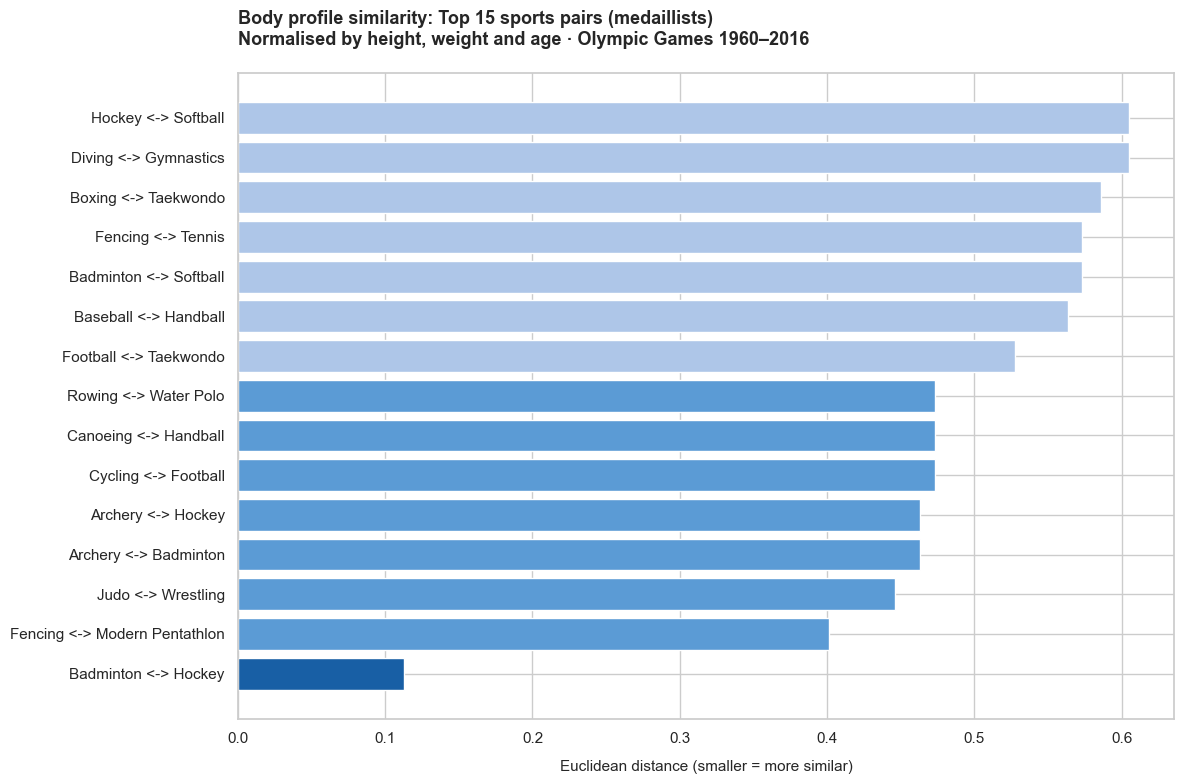

In [20]:
# Vizualize similar sport pairs

top_pairs_df = pairs_df.head(15).copy()
top_pairs_df['label'] = pairs_df['sport_A'] + " <-> " + pairs_df['sport_B']

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#185FA5' if d < 0.3 else '#5B9BD5' if d < 0.5 else '#AEC6E8' for d in top_pairs_df['distance']]

ax.barh(top_pairs_df['label'], top_pairs_df['distance'], color=colors, label='Distance')

ax.set_xlabel("Euclidean distance (smaller = more similar)", fontsize=11, labelpad=10)
ax.set_title("Body profile similarity: Top 15 sports pairs (medaillists)\n"
             "Normalised by height, weight and age · Olympic Games 1960–2016",
             fontsize=13, fontweight='bold', loc='left', pad=20)

plt.tight_layout()
plt.show()

**Result**
- **Badminton ↔ Hockey** is the most similar pair (distance 0.11). Badminton and hockey athletes have almost identical physical profiles in terms of height, weight and age.
- **Judo ↔ Wrestling** and **Fencing ↔ Modern Pentathlon** as natural transitions. Both pairs combine similar body profiles with related movement requirements — structurally, these are the most plausible transition paths.

### 5. Age and medal efficiency

In [21]:
medal_df = df[df['medal_name'].notna()]

bins = [0, 18, 22, 26, 30, 35, 45, 100]
labels = ['< 18', '18–22', '22–26', '26–30', '30–35', '35–45', '45+']

medal_df['age_group'] = pd.cut(
    medal_df['age_at_event'],
    bins=bins,
    labels=labels
)

display(medal_df)

C:\Users\Andre\AppData\Local\Temp\ipykernel_17796\23686306.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medal_df['age_group'] = pd.cut(


,name,sex,sport,year,medal_name,event_name,age_at_event,body_size_at_event,body_weight_at_event,country_name,age_group
6,Ragnhild Margrethe Aamodt,F,Handball,2008,Gold,Handball Women's Handball,27,1630.0,680.0,Norway,26–30
13,Willemien Aardenburg,F,Hockey,1988,Bronze,Hockey Women's Hockey,22,1660.0,600.0,Netherlands,18–22
14,Pepijn Aardewijn,M,Rowing,1996,Silver,Rowing Men's Lightweight Double Sculls,26,1890.0,720.0,Netherlands,22–26
24,Ann Kristin Aarnes,F,Football,1996,Bronze,Football Women's Football,23,1820.0,640.0,Norway,22–26
45,Giovanni Abagnale,M,Rowing,2016,Bronze,Rowing Men's Coxless Pairs,21,1980.0,900.0,Italy,18–22
...,...,...,...,...,...,...,...,...,...,...,...
165950,Henk Jan Zwolle,M,Rowing,1996,Gold,Rowing Men's Coxed Eights,31,1970.0,930.0,Netherlands,30–35
165957,Galina Ivanovna Zybina (-Fyodorova),F,Athletics,1964,Bronze,Athletics Women's Shot Put,33,1680.0,800.0,Russia,30–35
165959,Bogusaw Zych,M,Fencing,1980,Bronze,"Fencing Men's Foil, Team",28,1820.0,820.0,Poland,26–30
165970,Olesya Nikolayevna Zykina,F,Athletics,2000,Bronze,Athletics Women's 4 x 400 metres Relay,19,1710.0,640.0,Russia,18–22


In [22]:
gold_by_age = (medal_df.groupby('age_group').agg(
        total_medals=('medal_name', 'count'),
        gold_medals=('medal_name', lambda x: (x == 'Gold').sum())
    )
    .reset_index()
)

gold_by_age['gold_pct'] = (
    gold_by_age['gold_medals'] / gold_by_age['total_medals'] * 100
).round(1)

print(gold_by_age)

  age_group  total_medals  gold_medals  gold_pct
0      < 18          1370          481      35.1
1     18–22          5741         1924      33.5
2     22–26          8001         2637      33.0
3     26–30          5344         1746      32.7
4     30–35          2234          738      33.0
5     35–45           708          225      31.8
6       45+           129           39      30.2


C:\Users\Andre\AppData\Local\Temp\ipykernel_17796\875960949.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gold_by_age = (medal_df.groupby('age_group').agg(


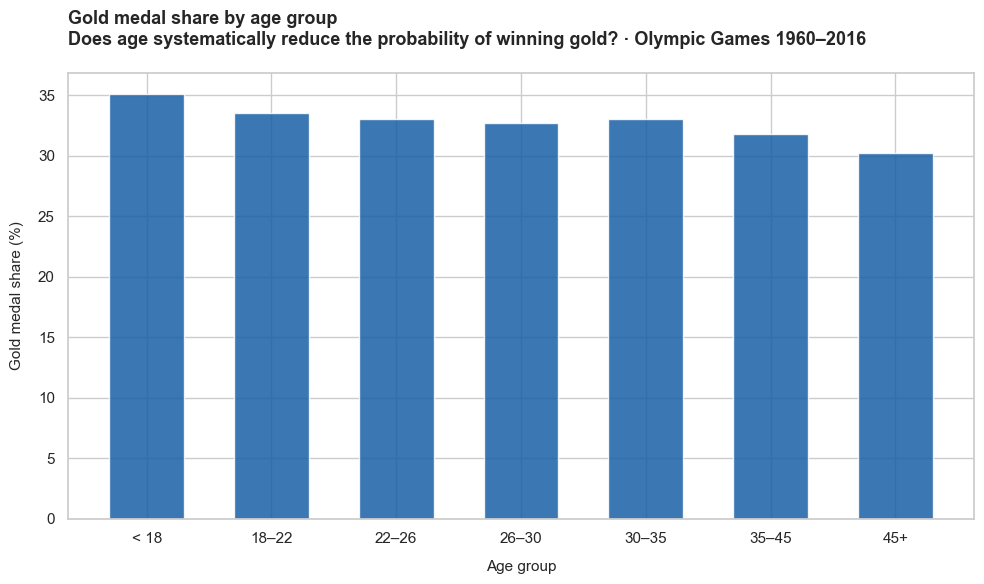

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    gold_by_age['age_group'],
    gold_by_age['gold_pct'],
    color='#185FA5',
    alpha=0.85,
    width=0.6
)

ax.set_xlabel('Age group', fontsize=11, labelpad=10)
ax.set_ylabel('Gold medal share (%)', fontsize=11, labelpad=10)
ax.set_title(
    'Gold medal share by age group\n'
    'Does age systematically reduce the probability of winning gold? · Olympic Games 1960–2016',
    fontsize=13, fontweight='bold', loc='left', pad=20
)

plt.tight_layout()
plt.show()

**Result:**  
The decline is statistically significant but so slight that age alone is not a reliable predictor of medal success. Experience and tactical maturity largely compensate for the physical decline.